In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import yfinance as yf

## 1. Load Polymarket SPX data

The `resolved` API field is always `False` regardless of actual settlement status.  
We infer settlement from prices: `p_up ∈ {0.0, 1.0}` → market closed.

In [2]:
df = pd.read_csv("data_processed/spx_daily_history.csv")
df["date"] = pd.to_datetime(df["date"]).dt.date

# infer settlement from prices (API resolved field is unreliable)
df["settled"] = df["p_up"].isin([0.0, 1.0])
df["outcome"] = df["p_up"].map({1.0: "Up", 0.0: "Down"})

settled = df[df["settled"]].copy()
live    = df[~df["settled"]].copy()

print(f"Total rows            : {len(df)}")
print(f"Settled markets       : {len(settled)}")
print(f"Live / unsettled      : {len(live)}")
df.tail(5)

Total rows            : 89
Settled markets       : 88
Live / unsettled      : 1


,date,slug,startDate,endDate,p_up,p_down,resolved,outcome,settled
84,2026-05-06,spx-up-or-down-on-may-6-2026,2026-05-05T12:02:32.638342Z,2026-05-06T20:00:00Z,1.0000,0.0000,False,Up,True
85,2026-05-07,spx-up-or-down-on-may-7-2026,2026-05-06T12:02:31.827382Z,2026-05-07T20:00:00Z,0.0000,1.0000,False,Down,True
86,2026-05-08,spx-up-or-down-on-may-8-2026,2026-05-07T12:05:47.034655Z,2026-05-08T20:00:00Z,1.0000,0.0000,False,Up,True
87,2026-05-11,spx-up-or-down-on-may-11-2026,2026-05-08T12:02:56.434931Z,2026-05-11T20:00:00Z,1.0000,0.0000,False,Up,True
88,2026-05-12,spx-up-or-down-on-may-12-2026,2026-05-11T12:05:58.30064Z,2026-05-12T20:00:00Z,0.0205,0.9795,False,NaN,False


## 2. Outcome distribution

Up days   :  48  (54.5%)
Down days :  40  (45.5%)


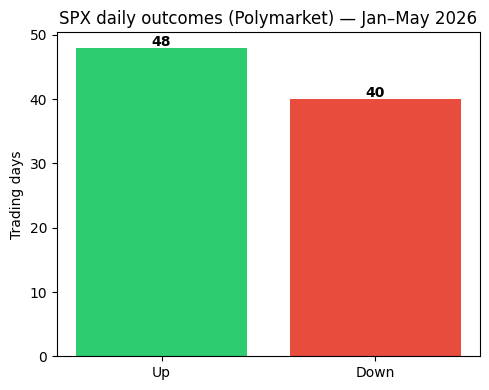

In [3]:
counts = settled["outcome"].value_counts()
up_n, down_n = counts.get("Up", 0), counts.get("Down", 0)
total = up_n + down_n

print(f"Up days   : {up_n:3d}  ({up_n/total*100:.1f}%)")
print(f"Down days : {down_n:3d}  ({down_n/total*100:.1f}%)")

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["Up", "Down"], [up_n, down_n], color=["#2ecc71", "#e74c3c"])
ax.set_ylabel("Trading days")
ax.set_title("SPX daily outcomes (Polymarket) — Jan–May 2026")
for i, v in enumerate([up_n, down_n]):
    ax.text(i, v + 0.3, str(v), ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

## 3. Fetch actual SPX returns (yfinance)

Cross-validate Polymarket outcomes against official SPX closing prices.

In [4]:
raw = yf.download("^GSPC", start="2026-01-01", end="2026-05-13",
                  auto_adjust=True, progress=False)
spx = raw[["Close"]].copy()
spx.index = pd.to_datetime(spx.index).date
spx.index.name = "date"
spx["return"]  = spx["Close"].pct_change()
spx["spx_out"] = spx["return"].apply(
    lambda r: "Up" if r > 0 else ("Down" if r < 0 else "Flat")
)
spx = spx.dropna().reset_index()

print(f"yfinance rows: {len(spx)}")
spx.tail(5)

yfinance rows: 89


Price,date,Close,return,spx_out
Ticker,,^GSPC,,
84,2026-05-06,7365.120117,0.014588,Up
85,2026-05-07,7337.109863,-0.003803,Down
86,2026-05-08,7398.930176,0.008426,Up
87,2026-05-11,7412.839844,0.001880,Up
88,2026-05-12,7375.819824,-0.004994,Down


## 4. Merge and cross-validate

In [9]:
merged = settled.merge(spx, on="date", how="inner")
merged["match"] = merged["outcome"] == merged["spx_out"]

agreement = merged["match"].mean()
mismatches = merged[~merged["match"]]

print(f"Matched days      : {len(merged)}")
print(f"Agreement rate    : {agreement:.1%}")
print(f"Mismatches        : {len(mismatches)}")
if len(mismatches):
    print("\nMismatch detail (Polymarket vs yfinance):")
    print(mismatches[["date", "outcome", "spx_out", "return"]].to_string(index=False))


Matched days      : 87
Agreement rate    : 100.0%
Mismatches        : 0


## 5. SPX close timeline with Up/Down shading

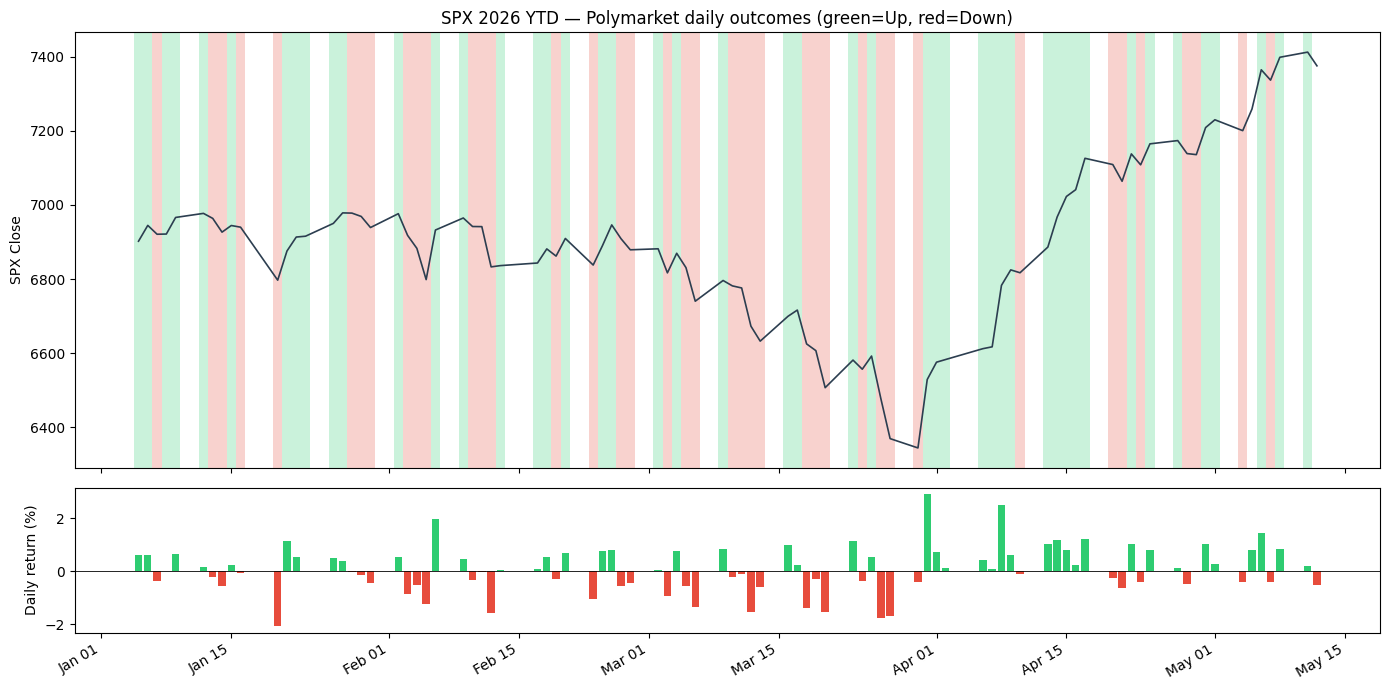

In [10]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True,
                                gridspec_kw={"height_ratios": [3, 1]})

# — SPX close
dates  = pd.to_datetime(spx["date"].astype(str))
closes = spx["Close"].values
ax1.plot(dates, closes, color="#2c3e50", linewidth=1.2)

# colour each day by Polymarket outcome
colour_map = {"Up": "#2ecc71", "Down": "#e74c3c"}
for _, row in merged.iterrows():
    d = pd.Timestamp(str(row["date"]))
    ax1.axvspan(d - pd.Timedelta(hours=12), d + pd.Timedelta(hours=12),
                color=colour_map.get(row["outcome"], "grey"), alpha=0.25, linewidth=0)

ax1.set_ylabel("SPX Close")
ax1.set_title("SPX 2026 YTD — Polymarket daily outcomes (green=Up, red=Down)")
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

# — Daily returns bar chart
returns = spx["return"].values * 100
colors  = ["#2ecc71" if r > 0 else "#e74c3c" for r in returns]
ax2.bar(dates, returns, color=colors, width=0.8)
ax2.axhline(0, color="black", linewidth=0.6)
ax2.set_ylabel("Daily return (%)")
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
fig.autofmt_xdate(rotation=30)
plt.tight_layout()
plt.show()